## Down Syndrome Data Exploration

### Common Imports

In [1]:
import pandas as pd
import pickle as pkl
import matplotlib.pyplot as plt
import seaborn as sns
import tkinter as tk
from tkinter import filedialog

In [2]:
# suppress warnings
import warnings

warnings.filterwarnings("ignore")

### Load Data

In [3]:
chunks = pkl.load(
    open("../../../data/2021/interim/down_syndrome/chunks_filtered.pkl", "rb")
)
target_chunks = pkl.load(
    open("../../../data/2021/interim/down_syndrome/target_chunks.pkl", "rb")
)
feature_importances = pkl.load(
    open("../../../data/2021/processed/down_syndrome/feature_importances_df.pkl", "rb")
)

In [4]:
df = pd.concat(chunks).reset_index(drop=True)
target = pd.concat(target_chunks).reset_index(drop=True)

df["target"] = target

### Feature Selection

We'll choose our top features by filtering for any with an importance > 0.01

In [5]:
top_features = feature_importances.loc[feature_importances["importance"] > 0.01]

top_features

,feature,importance
92,Numerical Pipeline__mothers_single_year_age,0.129795
94,Numerical Pipeline__prior_births_now_living,0.093165
100,Numerical Pipeline__pre_pregnancy_weight_recode,0.072668
107,Numerical Pipeline__BMI,0.066062
97,Numerical Pipeline__interval_since_last_live_b...,0.056888
99,Numerical Pipeline__interval_since_last_pregna...,0.046312
93,Numerical Pipeline__fathers_combined_age,0.041087
106,Numerical Pipeline__mothers_height_in_inches,0.033964
98,Numerical Pipeline__interval_since_last_other_...,0.033135
101,Numerical Pipeline__weight_gain_recode,0.024197


Of these, we'll focus on the following:

- Mother's Age
- Mother's BMI
- Mother's Race
- Mother's Hispanic Origin
- Cigarettes Before Pregnancy
- Pre-pregnancy Weight
- Prior Births Now Living
- Intervals Since Last Birth/Pregnancy
- Prior Terminations
- Father's Age
- Father's Race
- Father's Hispanic Origin



### Cleaning Up Encoded NAs

We'd like to view the raw data with NAs included for now, but some columns we're interested in have encoded missing values in a way that we need to account for manually.

In [6]:
df["fathers_combined_age"] = df["fathers_combined_age"].replace(99, pd.NA)
df["interval_since_last_live_birth"] = df["interval_since_last_live_birth"].replace(
    [888, 999], pd.NA
)
df["interval_since_last_other_pregnancy_recode"] = df[
    "interval_since_last_other_pregnancy_recode"
].replace([888, 999], pd.NA)
df["interval_since_last_pregnancy_recode"] = df[
    "interval_since_last_pregnancy_recode"
].replace([888, 999], pd.NA)
df["prior_other_terminations"] = df["prior_other_terminations"].replace(99, pd.NA)
df["prior_births_now_living"] = df["prior_births_now_living"].replace(99, pd.NA)
df["pre_pregnancy_weight_recode"] = df["pre_pregnancy_weight_recode"].replace(
    999, pd.NA
)
df["BMI"] = df["BMI"].replace(99.9, pd.NA)
df["cigarettes_before_pregnancy"] = df["cigarettes_before_pregnancy"].replace(99, pd.NA)
df["mothers_hispanic_origin_recode"] = df["mothers_hispanic_origin_recode"].replace(
    9, pd.NA
)
df["fathers_hispanic_origin"] = df["fathers_hispanic_origin"].replace(9, pd.NA)

In [7]:
df.describe()

,mothers_single_year_age,mothers_nativity,mothers_residence_status,mothers_race_recode_6,mothers_hispanic_origin,mothers_race_and_hispanic_origin,mothers_education,fathers_race_recode_6,fathers_race_and_hispanic_origin,fathers_education,...,pre_pregnancy_hypertension,gestational_hypertension,hypertension_eclampsia,previous_preterm_birth,infertility_treatment_used,previous_cesarean,no_risk_factors_reported,delivery_method_recode_7,delivery_method_recode_3,target
count,3.662380e+06,3.662380e+06,3.662380e+06,3.662380e+06,3662380.0,3.662380e+06,3.662380e+06,3.662380e+06,3.662380e+06,3.662380e+06,...,3.658534e+06,3.658534e+06,3.658534e+06,3.658534e+06,3.658534e+06,3.658534e+06,3.662380e+06,3.662380e+06,3.662380e+06,3.662380e+06
mean,2.940704e+01,1.218221e+00,1.353749e+00,1.518534e+00,6.0,2.982331e+00,4.519154e+00,2.877102e+00,3.584241e+00,4.949182e+00,...,2.719833e-02,9.117504e-02,2.766682e-03,3.799500e-02,2.203451e-02,1.535489e-01,6.666029e-01,1.801872e+00,1.324242e+00,8.052141e-04
std,5.771837e+00,4.183445e-01,5.387955e-01,1.118689e+00,0.0,2.569865e+00,1.821242e+00,3.064080e+00,2.941251e+00,2.284867e+00,...,1.626609e-01,2.878579e-01,5.252645e-02,1.911842e-01,1.467958e-01,3.605159e-01,5.457595e-01,1.168314e+00,4.944299e-01,3.709150e-02
min,1.200000e+01,1.000000e+00,1.000000e+00,1.000000e+00,6.0,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00
25%,2.500000e+01,1.000000e+00,1.000000e+00,1.000000e+00,6.0,1.000000e+00,3.000000e+00,1.000000e+00,1.000000e+00,3.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00
50%,3.000000e+01,1.000000e+00,1.000000e+00,1.000000e+00,6.0,1.000000e+00,4.000000e+00,1.000000e+00,2.000000e+00,4.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00
75%,3.400000e+01,1.000000e+00,2.000000e+00,2.000000e+00,6.0,7.000000e+00,6.000000e+00,4.000000e+00,7.000000e+00,6.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,3.000000e+00,2.000000e+00,0.000000e+00
max,5.000000e+01,3.000000e+00,4.000000e+00,6.000000e+00,6.0,8.000000e+00,9.000000e+00,9.000000e+00,9.000000e+00,9.000000e+00,...,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,9.000000e+00,9.000000e+00,9.000000e+00,2.000000e+00


In [8]:
missing_values_df = df.isna().sum().reset_index()

missing_values_df

,index,0
0,mothers_single_year_age,0
1,mothers_nativity,0
2,mothers_residence_status,0
3,mothers_race_recode_6,0
4,mothers_hispanic_origin,0
5,mothers_hispanic_origin_recode,35367
6,mothers_race_and_hispanic_origin,0
7,mothers_education,0
8,fathers_combined_age,411083
9,fathers_race_recode_6,0


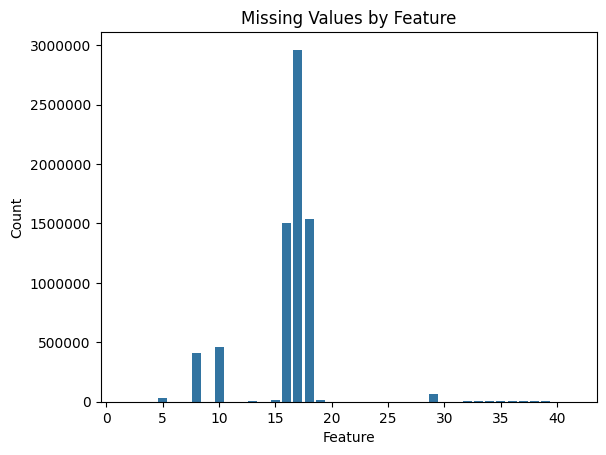

In [8]:
missing_values_ax = sns.barplot(
    data=missing_values_df,
    x=missing_values_df.index,
    y=0,
)
missing_values_ax.set_title("Missing Values by Feature")
missing_values_ax.set_xlabel("Feature")
missing_values_ax.set_ylabel("Count")
missing_values_ax.set_xticks(range(0, len(missing_values_df.index), 5))
missing_values_ax.set_yticks(
    range(0, 3000001, 500000), labels=range(0, 3000001, 500000)
)
plt.show()

We won't use any of the "interval since" features in the final model due to their significant NA ratio. We believe the information gained from those features may instead be inferred from other features, such as the mother's age.

### Univariate Visualizations

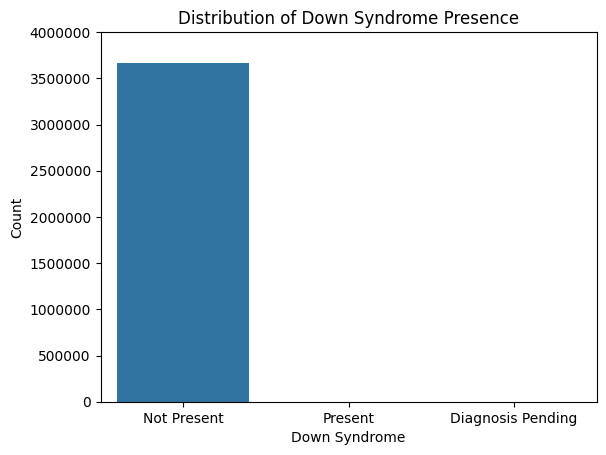

In [9]:
down_syndrome_value_counts = df["target"].value_counts()

down_syndrome_bar_ax = sns.barplot(
    x=down_syndrome_value_counts.index,
    y=down_syndrome_value_counts.values,
)

down_syndrome_bar_ax.set_title("Distribution of Down Syndrome Presence")
down_syndrome_bar_ax.set_xlabel("Down Syndrome")
down_syndrome_bar_ax.set_xticks(
    ticks=[0, 1, 2], labels=["Not Present", "Present", "Diagnosis Pending"]
)
down_syndrome_bar_ax.set_ylabel("Count")
down_syndrome_bar_ax.set_yticks(
    ticks=range(0, 4000001, 500000), labels=range(0, 4000001, 500000)
)
plt.show()

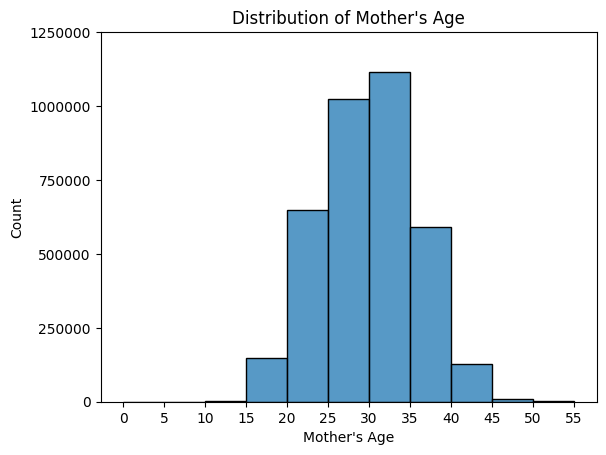

In [10]:
mothers_age_value_counts = df["mothers_single_year_age"].value_counts()

mothers_age_bar_ax = sns.histplot(
    x=mothers_age_value_counts.index,
    weights=mothers_age_value_counts.values,
    bins=range(0, 60, 5),
)
mothers_age_bar_ax.set_title("Distribution of Mother's Age")
mothers_age_bar_ax.set_xlabel("Mother's Age")
mothers_age_bar_ax.set_ylabel("Count")
mothers_age_bar_ax.set_xticks(range(0, 60, 5))
mothers_age_bar_ax.set_yticks(
    range(0, 1250001, 250000), labels=range(0, 1250001, 250000)
)
plt.show()

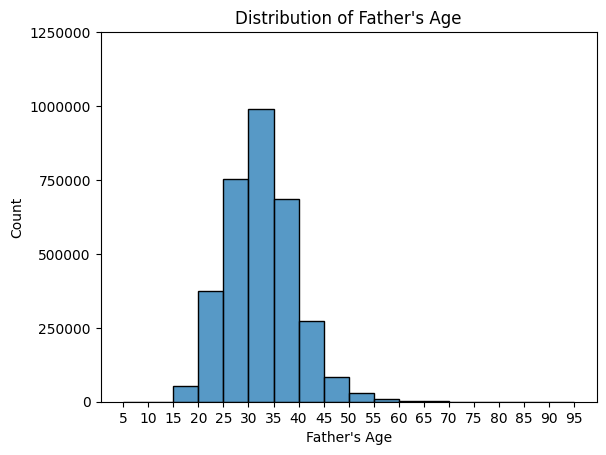

In [11]:
fathers_age_value_counts = df["fathers_combined_age"].value_counts()

fathers_age_bar_ax = sns.histplot(
    x=fathers_age_value_counts.index,
    weights=fathers_age_value_counts.values,
    bins=range(5, 99, 5),
)
fathers_age_bar_ax.set_title("Distribution of Father's Age")
fathers_age_bar_ax.set_xlabel("Father's Age")
fathers_age_bar_ax.set_ylabel("Count")
fathers_age_bar_ax.set_xticks(range(5, 99, 5))
fathers_age_bar_ax.set_yticks(
    range(0, 1250001, 250000), labels=range(0, 1250001, 250000)
)
plt.show()

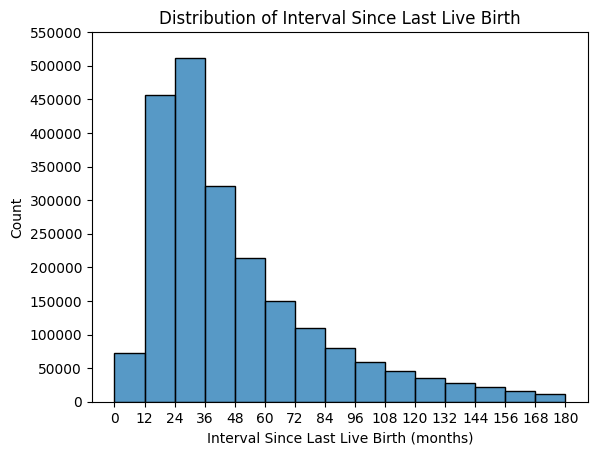

In [12]:
interval_since_last_live_birth_value_counts = df[
    "interval_since_last_live_birth"
].value_counts()

interval_since_last_live_birth_bar_ax = sns.histplot(
    x=interval_since_last_live_birth_value_counts.index,
    weights=interval_since_last_live_birth_value_counts.values,
    bins=range(0, 181, 12),
)
interval_since_last_live_birth_bar_ax.set_title(
    "Distribution of Interval Since Last Live Birth"
)
interval_since_last_live_birth_bar_ax.set_xlabel(
    "Interval Since Last Live Birth (months)"
)
interval_since_last_live_birth_bar_ax.set_ylabel("Count")
interval_since_last_live_birth_bar_ax.set_xticks(range(0, 181, 12))
interval_since_last_live_birth_bar_ax.set_yticks(
    range(0, 550001, 50000), labels=range(0, 550001, 50000)
)
plt.show()

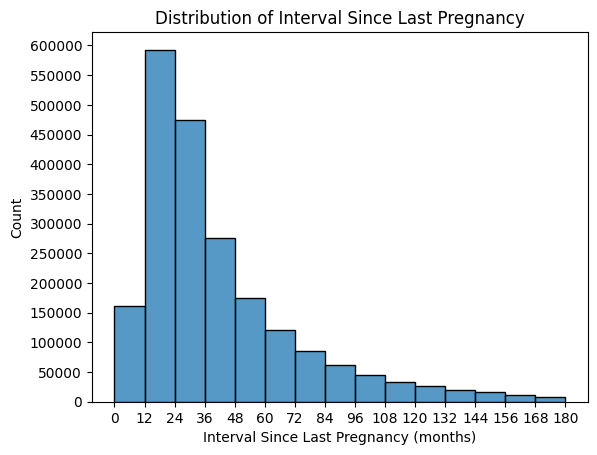

In [13]:
interval_since_last_pregnancy_recode_value_counts = df[
    "interval_since_last_pregnancy_recode"
].value_counts()

interval_since_last_pregnancy_recode_bar_ax = sns.histplot(
    x=interval_since_last_pregnancy_recode_value_counts.index,
    weights=interval_since_last_pregnancy_recode_value_counts.values,
    bins=range(0, 181, 12),
)
interval_since_last_pregnancy_recode_bar_ax.set_title(
    "Distribution of Interval Since Last Pregnancy"
)
interval_since_last_pregnancy_recode_bar_ax.set_xlabel(
    "Interval Since Last Pregnancy (months)"
)
interval_since_last_pregnancy_recode_bar_ax.set_ylabel("Count")
interval_since_last_pregnancy_recode_bar_ax.set_xticks(range(0, 181, 12))
interval_since_last_pregnancy_recode_bar_ax.set_yticks(
    range(0, 600001, 50000), labels=range(0, 600001, 50000)
)
plt.show()

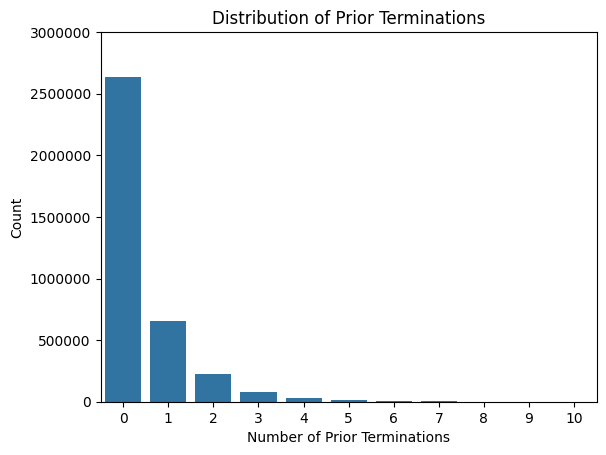

In [14]:
prior_terminations_value_counts = df["prior_other_terminations"].value_counts()

prior_terminations_bar_ax = sns.barplot(
    x=prior_terminations_value_counts.index,
    y=prior_terminations_value_counts.values,
)
prior_terminations_bar_ax.set_title("Distribution of Prior Terminations")
prior_terminations_bar_ax.set_xlabel("Number of Prior Terminations")
prior_terminations_bar_ax.set_ylabel("Count")
prior_terminations_bar_ax.set_xlim(-0.5, 10.5)
prior_terminations_bar_ax.set_xticks(range(0, 11))
prior_terminations_bar_ax.set_yticks(
    range(0, 3000001, 500000), labels=range(0, 3000001, 500000)
)
plt.show()

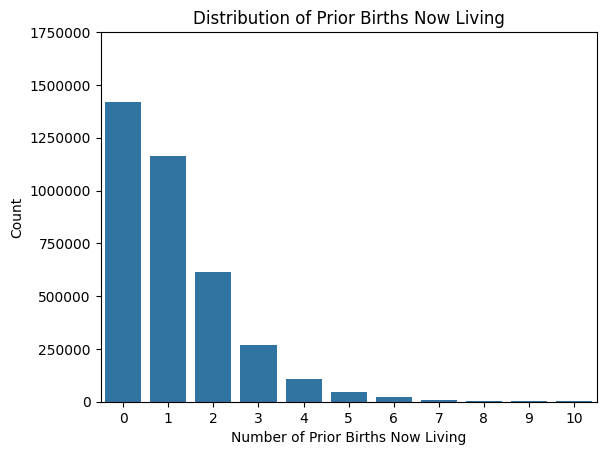

In [15]:
prior_births_now_living_value_counts = df["prior_births_now_living"].value_counts()

prior_births_now_living_bar_ax = sns.barplot(
    x=prior_births_now_living_value_counts.index,
    y=prior_births_now_living_value_counts.values,
)
prior_births_now_living_bar_ax.set_title("Distribution of Prior Births Now Living")
prior_births_now_living_bar_ax.set_xlabel("Number of Prior Births Now Living")
prior_births_now_living_bar_ax.set_ylabel("Count")
prior_births_now_living_bar_ax.set_xlim(-0.5, 10.5)
prior_births_now_living_bar_ax.set_xticks(range(0, 11))
prior_births_now_living_bar_ax.set_yticks(
    range(0, 1750001, 250000), labels=range(0, 1750001, 250000)
)
plt.show()

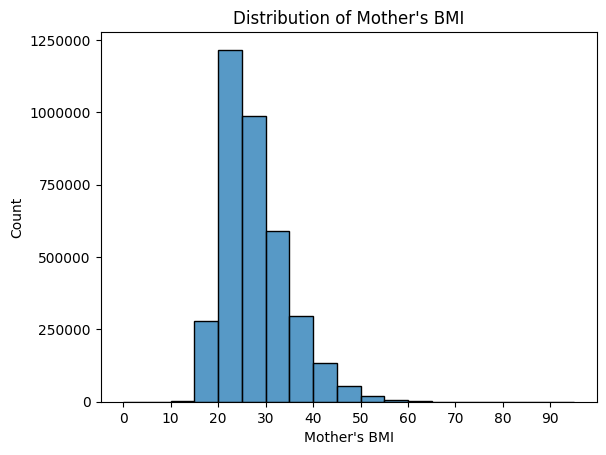

In [9]:
BMI_value_counts = df["BMI"].value_counts()

BMI_bar_ax = sns.histplot(
    x=BMI_value_counts.index, weights=BMI_value_counts.values, bins=range(0, 100, 5)
)
BMI_bar_ax.set_title("Distribution of Mother's BMI")
BMI_bar_ax.set_xlabel("Mother's BMI")
BMI_bar_ax.set_xticks(ticks=range(0, 100, 10))
BMI_bar_ax.set_yticks(range(0, 1250001, 250000), labels=range(0, 1250001, 250000))
BMI_bar_ax.set_ylabel("Count")
plt.show()

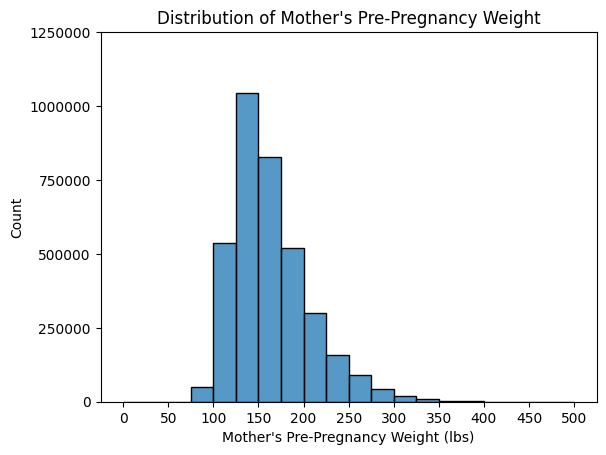

In [17]:
pre_pregnancy_weight_value_counts = df["pre_pregnancy_weight_recode"].value_counts()

pre_pregnancy_weight_bar_ax = sns.histplot(
    x=pre_pregnancy_weight_value_counts.index,
    weights=pre_pregnancy_weight_value_counts.values,
    bins=range(0, 501, 25),
)
pre_pregnancy_weight_bar_ax.set_title("Distribution of Mother's Pre-Pregnancy Weight")
pre_pregnancy_weight_bar_ax.set_xlabel("Mother's Pre-Pregnancy Weight (lbs)")
pre_pregnancy_weight_bar_ax.set_xticks(range(0, 501, 50))
pre_pregnancy_weight_bar_ax.set_yticks(
    range(0, 1250001, 250000), labels=range(0, 1250001, 250000)
)
pre_pregnancy_weight_bar_ax.set_ylabel("Count")
plt.show()

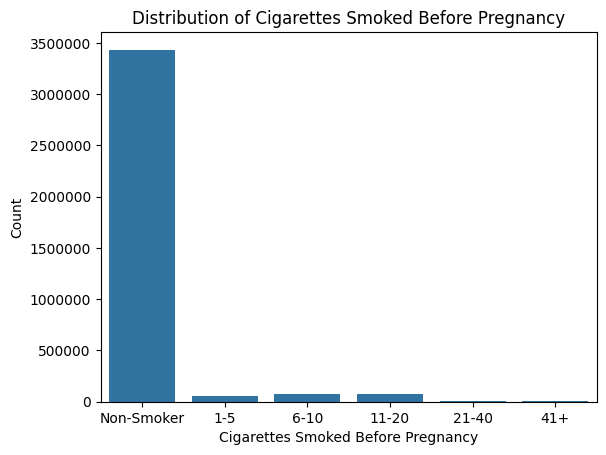

In [18]:
cigarettes_before_pregnancy_value_counts = df[
    "cigarettes_before_pregnancy_recode"
].value_counts()
cigarettes_before_pregnancy_value_counts = (
    cigarettes_before_pregnancy_value_counts.drop(6)
)

cigarettes_before_pregnancy_bar_ax = sns.barplot(
    x=cigarettes_before_pregnancy_value_counts.index,
    y=cigarettes_before_pregnancy_value_counts.values,
)
cigarettes_before_pregnancy_bar_ax.set_title(
    "Distribution of Cigarettes Smoked Before Pregnancy"
)
cigarettes_before_pregnancy_bar_ax.set_xlabel("Cigarettes Smoked Before Pregnancy")
cigarettes_before_pregnancy_bar_ax.set_xticklabels(
    ["Non-Smoker", "1-5", "6-10", "11-20", "21-40", "41+"]
)
cigarettes_before_pregnancy_bar_ax.set_ylabel("Count")
cigarettes_before_pregnancy_bar_ax.set_yticks(
    range(0, 3750001, 500000), labels=range(0, 3750001, 500000)
)

plt.show()

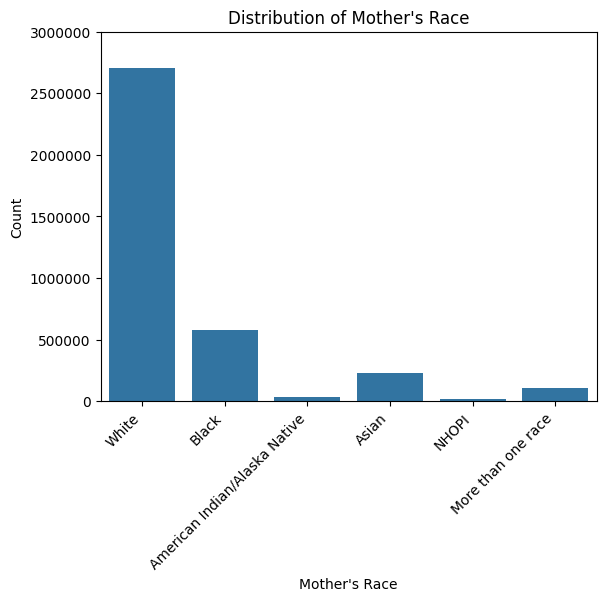

In [19]:
mothers_race_value_counts = df["mothers_race_recode_6"].value_counts()

mothers_race_ax = sns.barplot(
    x=mothers_race_value_counts.index,
    y=mothers_race_value_counts.values,
)
mothers_race_ax.set_title("Distribution of Mother's Race")
mothers_race_ax.set_xlabel("Mother's Race")
mothers_race_ax.set_ylabel("Count")
mothers_race_ax.set_yticks(range(0, 3000001, 500000), labels=range(0, 3000001, 500000))
mothers_race_ax.set_xticklabels(
    [
        "White",
        "Black",
        "American Indian/Alaska Native",
        "Asian",
        "NHOPI",
        "More than one race",
    ],
    rotation=45,
    ha="right",
)

plt.show()

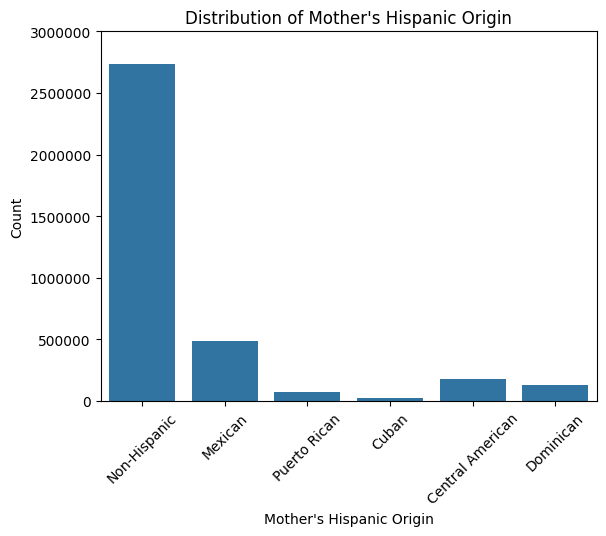

In [20]:
mothers_hispanic_origin_value_counts = df[
    "mothers_hispanic_origin_recode"
].value_counts()

mothers_hispanic_origin_bar_ax = sns.barplot(
    x=mothers_hispanic_origin_value_counts.index,
    y=mothers_hispanic_origin_value_counts.values,
)
mothers_hispanic_origin_bar_ax.set_title("Distribution of Mother's Hispanic Origin")
mothers_hispanic_origin_bar_ax.set_xlabel("Mother's Hispanic Origin")
mothers_hispanic_origin_bar_ax.set_ylabel("Count")
mothers_hispanic_origin_bar_ax.set_xticklabels(
    [
        "Non-Hispanic",
        "Mexican",
        "Puerto Rican",
        "Cuban",
        "Central American",
        "Dominican",
    ],
    rotation=45,
)
mothers_hispanic_origin_bar_ax.set_yticks(
    range(0, 3000001, 500000), labels=range(0, 3000001, 500000)
)

plt.show()

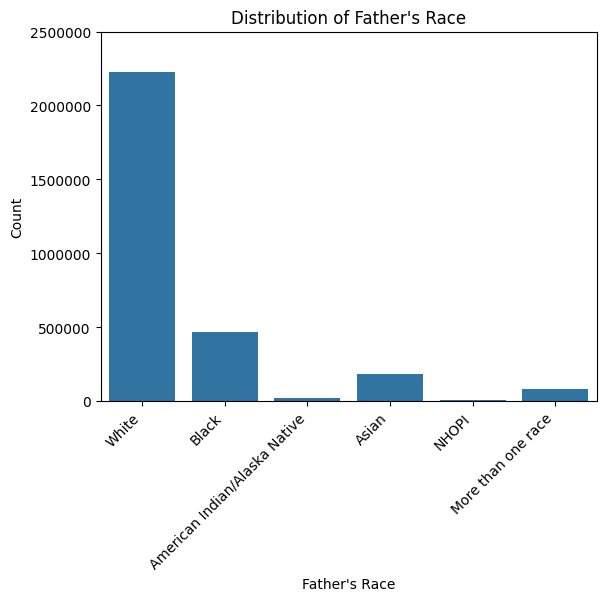

In [21]:
fathers_race_value_counts = df["fathers_race_recode_6"].value_counts()
fathers_race_value_counts = fathers_race_value_counts.drop(9)

fathers_race_ax = sns.barplot(
    x=fathers_race_value_counts.index,
    y=fathers_race_value_counts.values,
)
fathers_race_ax.set_title("Distribution of Father's Race")
fathers_race_ax.set_xlabel("Father's Race")
fathers_race_ax.set_ylabel("Count")
fathers_race_ax.set_yticks(range(0, 2500001, 500000), labels=range(0, 2500001, 500000))
fathers_race_ax.set_xticklabels(
    [
        "White",
        "Black",
        "American Indian/Alaska Native",
        "Asian",
        "NHOPI",
        "More than one race",
    ],
    rotation=45,
    ha="right",
)

plt.show()

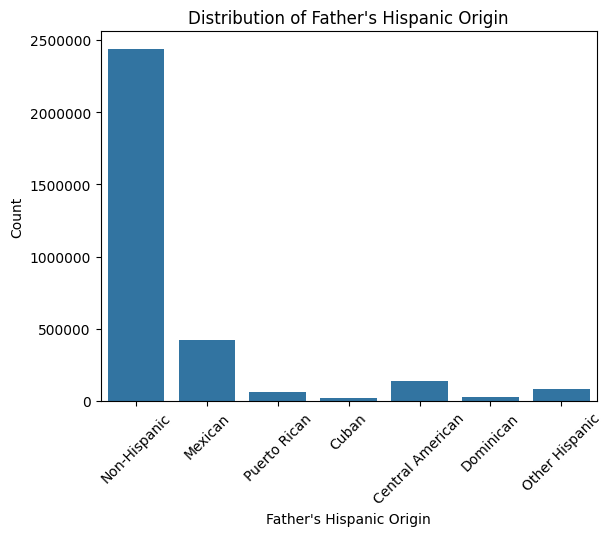

In [22]:
fathers_hispanic_origin_value_counts = df["fathers_hispanic_origin"].value_counts()

fathers_hispanic_origin_bar_ax = sns.barplot(
    x=fathers_hispanic_origin_value_counts.index,
    y=fathers_hispanic_origin_value_counts.values,
)
fathers_hispanic_origin_bar_ax.set_title("Distribution of Father's Hispanic Origin")
fathers_hispanic_origin_bar_ax.set_xlabel("Father's Hispanic Origin")
fathers_hispanic_origin_bar_ax.set_ylabel("Count")
fathers_hispanic_origin_bar_ax.set_xticklabels(
    [
        "Non-Hispanic",
        "Mexican",
        "Puerto Rican",
        "Cuban",
        "Central American",
        "Dominican",
        "Other Hispanic",
    ],
    rotation=45,
)
fathers_hispanic_origin_bar_ax.set_yticks(
    range(0, 2500001, 500000), labels=range(0, 2500001, 500000)
)

plt.show()

### Bivariate Visualizations

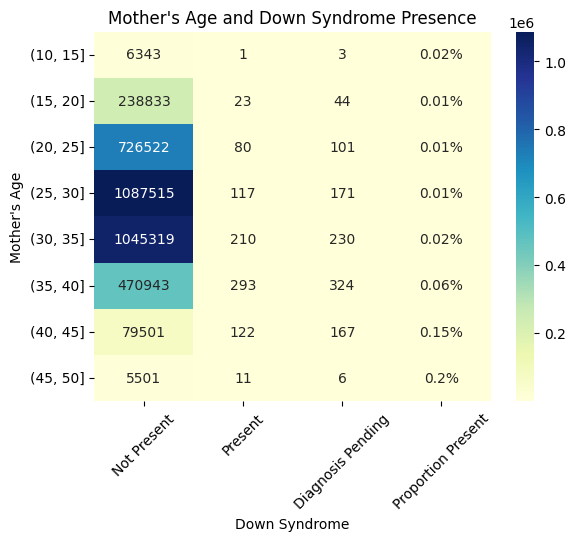

In [23]:
mothers_age_cross_tab = pd.crosstab(
    pd.cut(df["mothers_single_year_age"], bins=range(0, 61, 5)), df["target"]
)
mothers_age_cross_tab["proportion"] = (
    round(
        mothers_age_cross_tab[1].astype(float)
        / (
            mothers_age_cross_tab[0].astype(float)
            + mothers_age_cross_tab[1].astype(float)
            + mothers_age_cross_tab[2].astype(float)
        ),
        4,
    )
    * 100
)

annotation_matrix = mothers_age_cross_tab.copy()
annotation_matrix[0:2] = annotation_matrix[0:2].astype(int)
annotation_matrix["proportion"] = round(mothers_age_cross_tab["proportion"], 2)
annotation_matrix["proportion"] = annotation_matrix["proportion"].astype(str) + "%"

mothers_age_cross_tab_ax = sns.heatmap(
    mothers_age_cross_tab, cmap="YlGnBu", annot=annotation_matrix.values, fmt=""
)
mothers_age_cross_tab_ax.set_title("Mother's Age and Down Syndrome Presence")
mothers_age_cross_tab_ax.set_xlabel("Down Syndrome")
mothers_age_cross_tab_ax.set_xticklabels(
    ["Not Present", "Present", "Diagnosis Pending", "Proportion Present"], rotation=45
)
mothers_age_cross_tab_ax.set_ylabel("Mother's Age")
plt.show()

As the mother's age increases, so does the likelihood of Down syndrome.

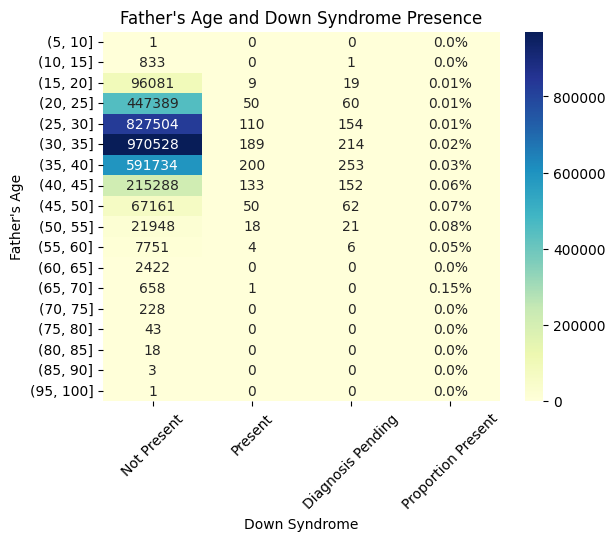

In [24]:
fathers_age_cross_tab = pd.crosstab(
    pd.cut(
        df["fathers_combined_age"].dropna(),
        bins=range(0, 101, 5),
    ),
    target,
)
fathers_age_cross_tab["proportion"] = (
    round(
        fathers_age_cross_tab[1].astype(float)
        / (
            fathers_age_cross_tab[0]
            + fathers_age_cross_tab[1]
            + fathers_age_cross_tab[2]
        ),
        4,
    )
    * 100
)

annotation_matrix = fathers_age_cross_tab.copy()
annotation_matrix[0:2] = annotation_matrix[0:2].astype(int)
annotation_matrix["proportion"] = round(fathers_age_cross_tab["proportion"], 2)
annotation_matrix["proportion"] = annotation_matrix["proportion"].astype(str) + "%"

fathers_age_cross_tab_ax = sns.heatmap(
    fathers_age_cross_tab, cmap="YlGnBu", annot=annotation_matrix.values, fmt=""
)
fathers_age_cross_tab_ax.set_title("Father's Age and Down Syndrome Presence")
fathers_age_cross_tab_ax.set_xlabel("Down Syndrome")
fathers_age_cross_tab_ax.set_xticklabels(
    ["Not Present", "Present", "Diagnosis Pending", "Proportion Present"], rotation=45
)
fathers_age_cross_tab_ax.set_ylabel("Father's Age")

plt.show()

Similarly, the likelihood of Down syndrome increases with the father's age.

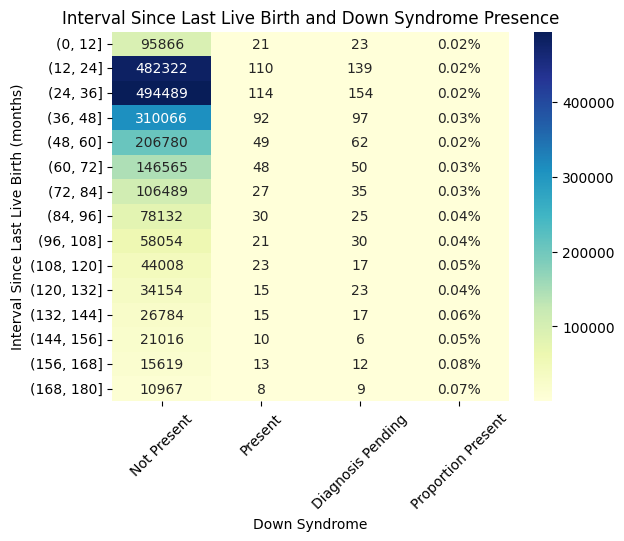

In [25]:
interval_since_last_live_birth_cross_tab = pd.crosstab(
    pd.cut(
        df["interval_since_last_live_birth"].dropna(),
        bins=range(0, 181, 12),
    ),
    df["target"],
)
interval_since_last_live_birth_cross_tab["proportion"] = (
    round(
        interval_since_last_live_birth_cross_tab[1].astype(float)
        / (
            interval_since_last_live_birth_cross_tab[0]
            + interval_since_last_live_birth_cross_tab[1]
            + interval_since_last_live_birth_cross_tab[2]
        ),
        4,
    )
    * 100
)

annotation_matrix = interval_since_last_live_birth_cross_tab.copy()
annotation_matrix[0:2] = annotation_matrix[0:2].astype(int)
annotation_matrix["proportion"] = round(
    interval_since_last_live_birth_cross_tab["proportion"], 2
)
annotation_matrix["proportion"] = annotation_matrix["proportion"].astype(str) + "%"

interval_since_last_live_birth_cross_tab_ax = sns.heatmap(
    interval_since_last_live_birth_cross_tab,
    cmap="YlGnBu",
    annot=annotation_matrix.values,
    fmt="",
)
interval_since_last_live_birth_cross_tab_ax.set_title(
    "Interval Since Last Live Birth and Down Syndrome Presence"
)
interval_since_last_live_birth_cross_tab_ax.set_xlabel("Down Syndrome")
interval_since_last_live_birth_cross_tab_ax.set_xticklabels(
    ["Not Present", "Present", "Diagnosis Pending", "Proportion Present"], rotation=45
)
interval_since_last_live_birth_cross_tab_ax.set_ylabel(
    "Interval Since Last Live Birth (months)"
)
plt.show()

The longer a couple waits between having one child and the next, the higher the likelihood of Down syndrome. However, this likely has a high correlation with parental age, so we will not include it in the final model.

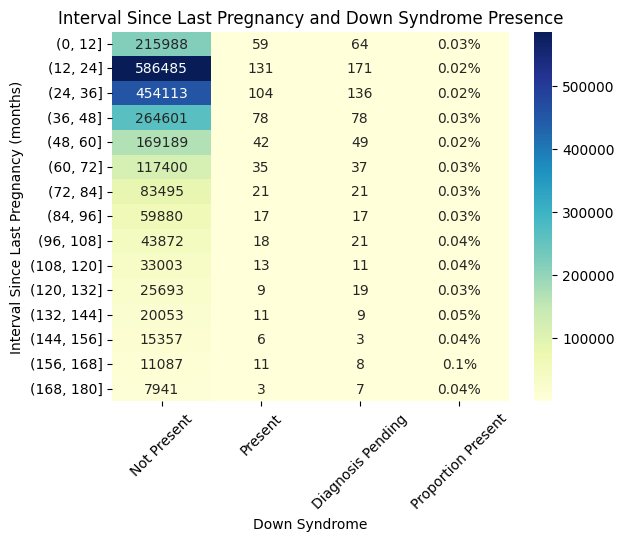

In [26]:
interval_since_last_pregnancy_cross_tab = pd.crosstab(
    pd.cut(
        df["interval_since_last_pregnancy_recode"].dropna(),
        bins=range(0, 181, 12),
    ),
    df["target"],
)
interval_since_last_pregnancy_cross_tab["proportion"] = (
    round(
        interval_since_last_pregnancy_cross_tab[1].astype(float)
        / (
            interval_since_last_pregnancy_cross_tab[0]
            + interval_since_last_pregnancy_cross_tab[1]
            + interval_since_last_pregnancy_cross_tab[2]
        ),
        4,
    )
    * 100
)

annotation_matrix = interval_since_last_pregnancy_cross_tab.copy()
annotation_matrix[0:2] = annotation_matrix[0:2].astype(int)
annotation_matrix["proportion"] = round(
    interval_since_last_pregnancy_cross_tab["proportion"], 2
)
annotation_matrix["proportion"] = annotation_matrix["proportion"].astype(str) + "%"

interval_since_last_pregnancy_cross_tab_ax = sns.heatmap(
    interval_since_last_pregnancy_cross_tab,
    cmap="YlGnBu",
    annot=annotation_matrix.values,
    fmt="",
)
interval_since_last_pregnancy_cross_tab_ax.set_title(
    "Interval Since Last Pregnancy and Down Syndrome Presence"
)
interval_since_last_pregnancy_cross_tab_ax.set_xlabel("Down Syndrome")
interval_since_last_pregnancy_cross_tab_ax.set_xticklabels(
    ["Not Present", "Present", "Diagnosis Pending", "Proportion Present"], rotation=45
)
interval_since_last_pregnancy_cross_tab_ax.set_ylabel(
    "Interval Since Last Pregnancy (months)"
)

plt.show()

Similarly, the longer a couple waits between pregnancies, the higher the likelihood of Down syndrome. However, this likely has a high correlation with parental age, so we will not include it in the final model.

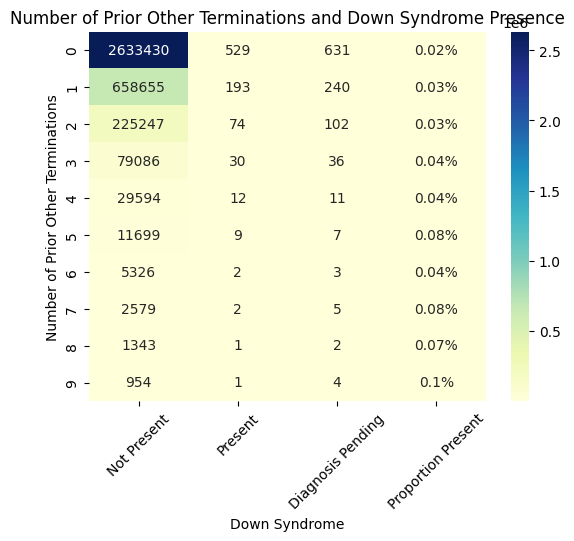

In [27]:
prior_other_terminations_cross_tab = pd.crosstab(
    df["prior_other_terminations"].dropna(), df["target"]
)
prior_other_terminations_cross_tab["proportion"] = (
    round(
        prior_other_terminations_cross_tab[1].astype(float)
        / (
            prior_other_terminations_cross_tab[0]
            + prior_other_terminations_cross_tab[1]
            + prior_other_terminations_cross_tab[2]
        ),
        4,
    )
    * 100
)

annotation_matrix = prior_other_terminations_cross_tab.iloc[0:10, :].copy()
annotation_matrix[0:2] = annotation_matrix[0:2].astype(int)
annotation_matrix["proportion"] = round(
    prior_other_terminations_cross_tab["proportion"], 2
)
annotation_matrix["proportion"] = annotation_matrix["proportion"].astype(str) + "%"

prior_other_terminations_cross_tab_ax = sns.heatmap(
    prior_other_terminations_cross_tab.iloc[0:10, :],
    cmap="YlGnBu",
    annot=annotation_matrix.values,
    fmt="",
)
prior_other_terminations_cross_tab_ax.set_title(
    "Number of Prior Other Terminations and Down Syndrome Presence"
)
prior_other_terminations_cross_tab_ax.set_xlabel("Down Syndrome")
prior_other_terminations_cross_tab_ax.set_xticklabels(
    ["Not Present", "Present", "Diagnosis Pending", "Proportion Present"], rotation=45
)
prior_other_terminations_cross_tab_ax.set_ylabel("Number of Prior Other Terminations")

plt.show()

Number of prior terminations appears to have some bearing on Down syndrome rates, but the data does not distinguish between miscarriages and voluntary terminations. This feature would be more relevant to our model if it only encompassed voluntary terminations. As it is, we will not include it.

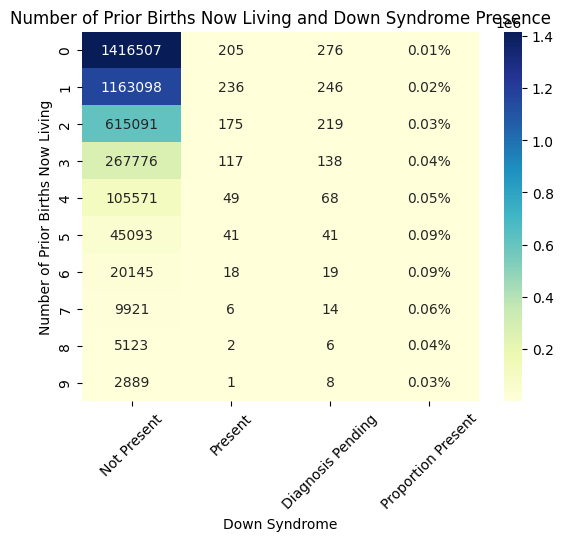

In [28]:
prior_births_now_living_cross_tab = pd.crosstab(
    df["prior_births_now_living"].dropna(), df["target"]
)
prior_births_now_living_cross_tab["proportion"] = (
    round(
        prior_births_now_living_cross_tab[1].astype(float)
        / (
            prior_births_now_living_cross_tab[0]
            + prior_births_now_living_cross_tab[1]
            + prior_births_now_living_cross_tab[2]
        ),
        4,
    )
    * 100
)

annotation_matrix = prior_births_now_living_cross_tab.iloc[0:10, :].copy()
annotation_matrix[0:2] = annotation_matrix[0:2].astype(int)
annotation_matrix["proportion"] = round(
    prior_births_now_living_cross_tab["proportion"], 2
)
annotation_matrix["proportion"] = annotation_matrix["proportion"].astype(str) + "%"

prior_births_now_living_cross_tab_ax = sns.heatmap(
    prior_births_now_living_cross_tab.iloc[0:10, :],
    cmap="YlGnBu",
    annot=annotation_matrix.values,
    fmt="",
)
prior_births_now_living_cross_tab_ax.set_title(
    "Number of Prior Births Now Living and Down Syndrome Presence"
)
prior_births_now_living_cross_tab_ax.set_xlabel("Down Syndrome")
prior_births_now_living_cross_tab_ax.set_xticklabels(
    ["Not Present", "Present", "Diagnosis Pending", "Proportion Present"], rotation=45
)
prior_births_now_living_cross_tab_ax.set_ylabel("Number of Prior Births Now Living")

plt.show()

Similarly to our "interval between" features, number of prior births appears to have a positive relationship with Down syndrome rates. However, this is likely due to increased parental age with higher numbers of births.

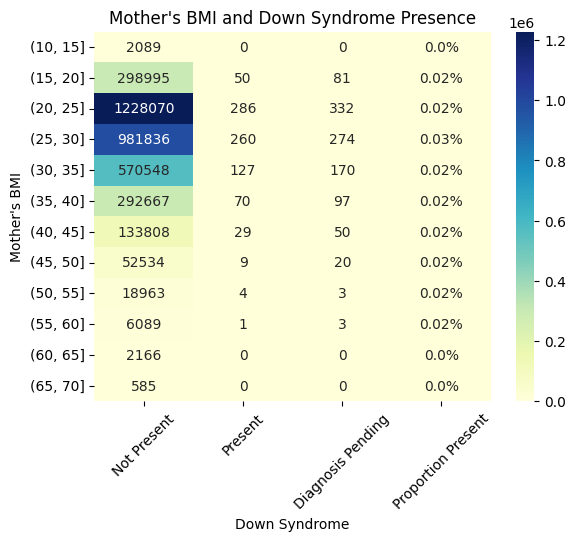

In [10]:
BMI_cross_tab = pd.crosstab(
    pd.cut(df["BMI"].dropna(), bins=range(0, 101, 5)), df["target"]
)
BMI_cross_tab["proportion"] = (
    round(
        BMI_cross_tab[1].astype(float)
        / (BMI_cross_tab[0] + BMI_cross_tab[1] + BMI_cross_tab[2]),
        4,
    )
    * 100
)

annotation_matrix = BMI_cross_tab.copy()
annotation_matrix[0:2] = annotation_matrix[0:2].astype(int)
annotation_matrix["proportion"] = round(BMI_cross_tab["proportion"], 2)
annotation_matrix["proportion"] = annotation_matrix["proportion"].astype(str) + "%"

BMI_cross_tab_ax = sns.heatmap(
    BMI_cross_tab, cmap="YlGnBu", annot=annotation_matrix.values, fmt=""
)
BMI_cross_tab_ax.set_title("Mother's BMI and Down Syndrome Presence")
BMI_cross_tab_ax.set_xlabel("Down Syndrome")
BMI_cross_tab_ax.set_xticklabels(
    ["Not Present", "Present", "Diagnosis Pending", "Proportion Present"], rotation=45
)
BMI_cross_tab_ax.set_ylabel("Mother's BMI")

plt.show()

Largely, BMI does not appear to have any bearing on Down syndrome rates.

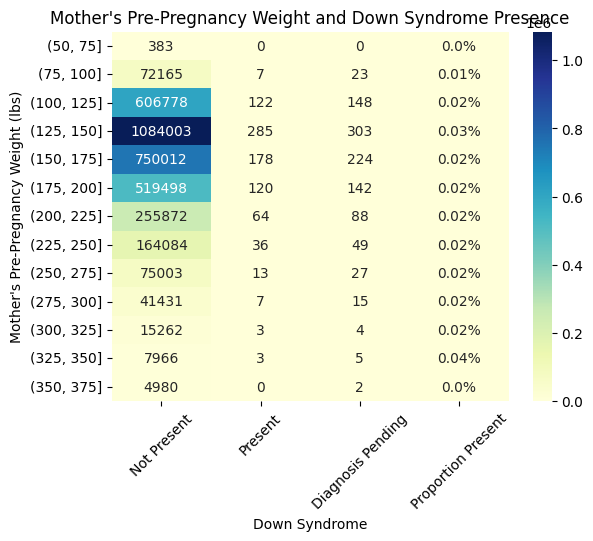

In [30]:
pre_pregnancy_weight_cross_tab = pd.crosstab(
    pd.cut(df["pre_pregnancy_weight_recode"].dropna(), bins=range(0, 501, 25)),
    df["target"],
)
pre_pregnancy_weight_cross_tab["proportion"] = (
    round(
        pre_pregnancy_weight_cross_tab[1].astype(float)
        / (
            pre_pregnancy_weight_cross_tab[0]
            + pre_pregnancy_weight_cross_tab[1]
            + pre_pregnancy_weight_cross_tab[2]
        ),
        4,
    )
    * 100
)

annotation_matrix = pre_pregnancy_weight_cross_tab.copy()
annotation_matrix[0:2] = annotation_matrix[0:2].astype(int)
annotation_matrix["proportion"] = round(pre_pregnancy_weight_cross_tab["proportion"], 2)
annotation_matrix["proportion"] = annotation_matrix["proportion"].astype(str) + "%"

pre_pregnancy_weight_cross_tab_ax = sns.heatmap(
    pre_pregnancy_weight_cross_tab,
    cmap="YlGnBu",
    annot=annotation_matrix.values,
    fmt="",
)
pre_pregnancy_weight_cross_tab_ax.set_title(
    "Mother's Pre-Pregnancy Weight and Down Syndrome Presence"
)
pre_pregnancy_weight_cross_tab_ax.set_xlabel("Down Syndrome")
pre_pregnancy_weight_cross_tab_ax.set_xticklabels(
    ["Not Present", "Present", "Diagnosis Pending", "Proportion Present"], rotation=45
)
pre_pregnancy_weight_cross_tab_ax.set_ylabel("Mother's Pre-Pregnancy Weight (lbs)")

plt.show()

The same can be said of pre-pregnancy weight.

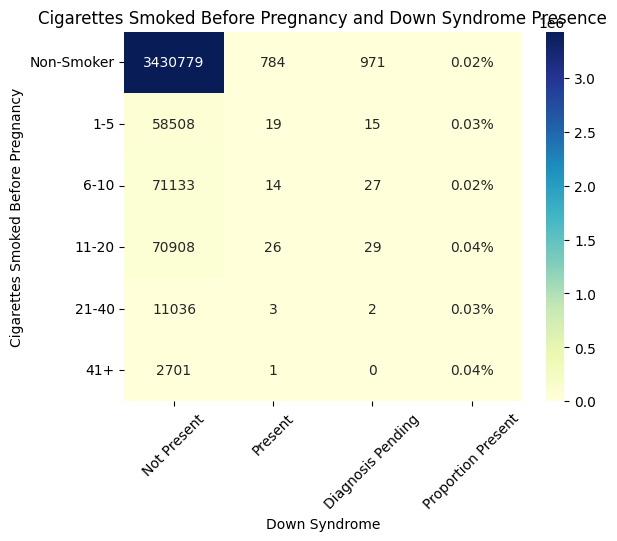

In [31]:
cigarettes_before_pregnancy_cross_tab = pd.crosstab(
    df[df["cigarettes_before_pregnancy_recode"] != 6][
        "cigarettes_before_pregnancy_recode"
    ].dropna(),
    df["target"],
)
cigarettes_before_pregnancy_cross_tab["proportion"] = (
    round(
        cigarettes_before_pregnancy_cross_tab[1].astype(float)
        / (
            cigarettes_before_pregnancy_cross_tab[0]
            + cigarettes_before_pregnancy_cross_tab[1]
            + cigarettes_before_pregnancy_cross_tab[2]
        ),
        4,
    )
    * 100
)

annotation_matrix = cigarettes_before_pregnancy_cross_tab.copy()
annotation_matrix[0:2] = annotation_matrix[0:2].astype(int)
annotation_matrix["proportion"] = round(
    cigarettes_before_pregnancy_cross_tab["proportion"], 2
)
annotation_matrix["proportion"] = annotation_matrix["proportion"].astype(str) + "%"

cigarettes_before_pregnancy_cross_tab_ax = sns.heatmap(
    cigarettes_before_pregnancy_cross_tab,
    cmap="YlGnBu",
    annot=annotation_matrix.values,
    fmt="",
)
cigarettes_before_pregnancy_cross_tab_ax.set_title(
    "Cigarettes Smoked Before Pregnancy and Down Syndrome Presence"
)
cigarettes_before_pregnancy_cross_tab_ax.set_xlabel("Down Syndrome")
cigarettes_before_pregnancy_cross_tab_ax.set_xticklabels(
    ["Not Present", "Present", "Diagnosis Pending", "Proportion Present"], rotation=45
)
cigarettes_before_pregnancy_cross_tab_ax.set_ylabel(
    "Cigarettes Smoked Before Pregnancy"
)
cigarettes_before_pregnancy_cross_tab_ax.set_yticklabels(
    ["Non-Smoker", "1-5", "6-10", "11-20", "21-40", "41+"], rotation=0
)

plt.show()

Cigarette use before pregnancy does not appear to have a strong relationship with Down syndrome rates.

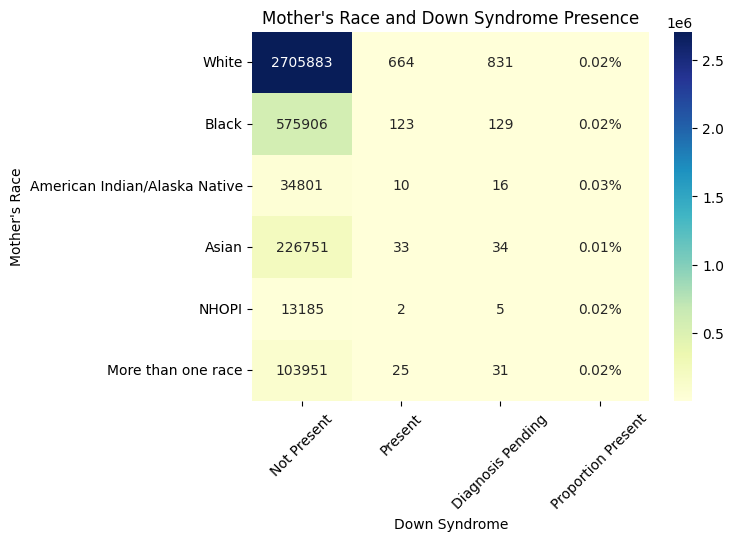

In [32]:
mothers_race_cross_tab = pd.crosstab(df["mothers_race_recode_6"], df["target"])
mothers_race_cross_tab["proportion"] = (
    round(
        mothers_race_cross_tab[1].astype(float)
        / (
            mothers_race_cross_tab[0]
            + mothers_race_cross_tab[1]
            + mothers_race_cross_tab[2]
        ),
        4,
    )
    * 100
)

annotation_matrix = mothers_race_cross_tab.copy()
annotation_matrix[0:2] = annotation_matrix[0:2].astype(int)
annotation_matrix["proportion"] = round(mothers_race_cross_tab["proportion"], 2)
annotation_matrix["proportion"] = annotation_matrix["proportion"].astype(str) + "%"

mothers_race_cross_tab_ax = sns.heatmap(
    mothers_race_cross_tab, cmap="YlGnBu", annot=annotation_matrix.values, fmt=""
)
mothers_race_cross_tab_ax.set_title("Mother's Race and Down Syndrome Presence")
mothers_race_cross_tab_ax.set_xlabel("Down Syndrome")
mothers_race_cross_tab_ax.set_xticklabels(
    ["Not Present", "Present", "Diagnosis Pending", "Proportion Present"], rotation=45
)
mothers_race_cross_tab_ax.set_yticklabels(
    [
        "White",
        "Black",
        "American Indian/Alaska Native",
        "Asian",
        "NHOPI",
        "More than one race",
    ],
    rotation=0,
)
mothers_race_cross_tab_ax.set_ylabel("Mother's Race")

plt.show()

Down syndrome rates appear highest among the AIAH population, though research indicates that this is due to cultural factors rather than genetic. The same can be said of the lower rate amoung the Asian population.

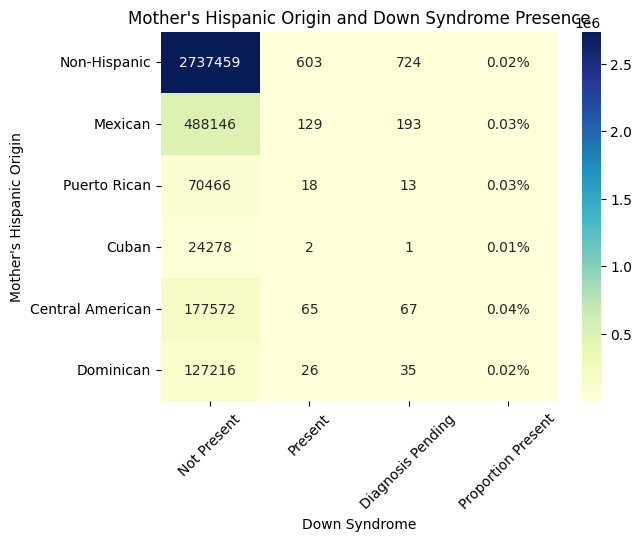

In [33]:
mothers_hispanic_origin_cross_tab = pd.crosstab(
    df["mothers_hispanic_origin_recode"], df["target"]
)
mothers_hispanic_origin_cross_tab["proportion"] = (
    round(
        mothers_hispanic_origin_cross_tab[1].astype(float)
        / (
            mothers_hispanic_origin_cross_tab[0]
            + mothers_hispanic_origin_cross_tab[1]
            + mothers_hispanic_origin_cross_tab[2]
        ),
        4,
    )
    * 100
)

annotation_matrix = mothers_hispanic_origin_cross_tab.copy()
annotation_matrix[0:2] = annotation_matrix[0:2].astype(int)
annotation_matrix["proportion"] = round(
    mothers_hispanic_origin_cross_tab["proportion"], 2
)
annotation_matrix["proportion"] = annotation_matrix["proportion"].astype(str) + "%"

mothers_hispanic_origin_cross_tab_ax = sns.heatmap(
    mothers_hispanic_origin_cross_tab,
    cmap="YlGnBu",
    annot=annotation_matrix.values,
    fmt="",
)
mothers_hispanic_origin_cross_tab_ax.set_title(
    "Mother's Hispanic Origin and Down Syndrome Presence"
)
mothers_hispanic_origin_cross_tab_ax.set_xlabel("Down Syndrome")
mothers_hispanic_origin_cross_tab_ax.set_xticklabels(
    ["Not Present", "Present", "Diagnosis Pending", "Proportion Present"], rotation=45
)
mothers_hispanic_origin_cross_tab_ax.set_yticklabels(
    [
        "Non-Hispanic",
        "Mexican",
        "Puerto Rican",
        "Cuban",
        "Central American",
        "Dominican",
    ],
    rotation=0,
)
mothers_hispanic_origin_cross_tab_ax.set_ylabel("Mother's Hispanic Origin")

plt.show()

Similarly, Down sydrome rates are higher in the Hispanic population due to cultural factors.

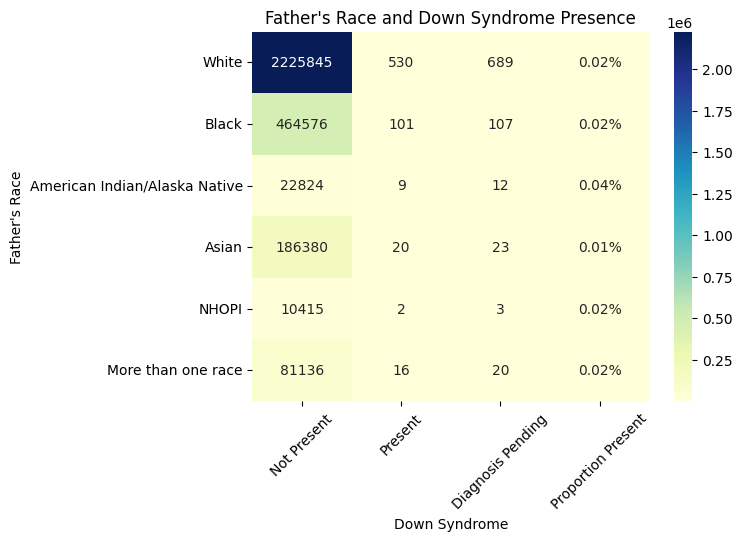

In [34]:
fathers_race_cross_tab = pd.crosstab(
    df[df["fathers_race_recode_6"] != 9]["fathers_race_recode_6"], df["target"]
)
fathers_race_cross_tab["proportion"] = (
    round(
        fathers_race_cross_tab[1].astype(float)
        / (
            fathers_race_cross_tab[0]
            + fathers_race_cross_tab[1]
            + fathers_race_cross_tab[2]
        ),
        4,
    )
    * 100
)

annotation_matrix = fathers_race_cross_tab.copy()
annotation_matrix[0:2] = annotation_matrix[0:2].astype(int)
annotation_matrix["proportion"] = round(fathers_race_cross_tab["proportion"], 2)
annotation_matrix["proportion"] = annotation_matrix["proportion"].astype(str) + "%"

fathers_race_cross_tab_ax = sns.heatmap(
    fathers_race_cross_tab, cmap="YlGnBu", annot=annotation_matrix.values, fmt=""
)
fathers_race_cross_tab_ax.set_title("Father's Race and Down Syndrome Presence")
fathers_race_cross_tab_ax.set_xlabel("Down Syndrome")
fathers_race_cross_tab_ax.set_xticklabels(
    ["Not Present", "Present", "Diagnosis Pending", "Proportion Present"], rotation=45
)
fathers_race_cross_tab_ax.set_yticklabels(
    [
        "White",
        "Black",
        "American Indian/Alaska Native",
        "Asian",
        "NHOPI",
        "More than one race",
    ],
    rotation=0,
)
fathers_race_cross_tab_ax.set_ylabel("Father's Race")

plt.show()

We see the same trends with the father's race as with the mother's.

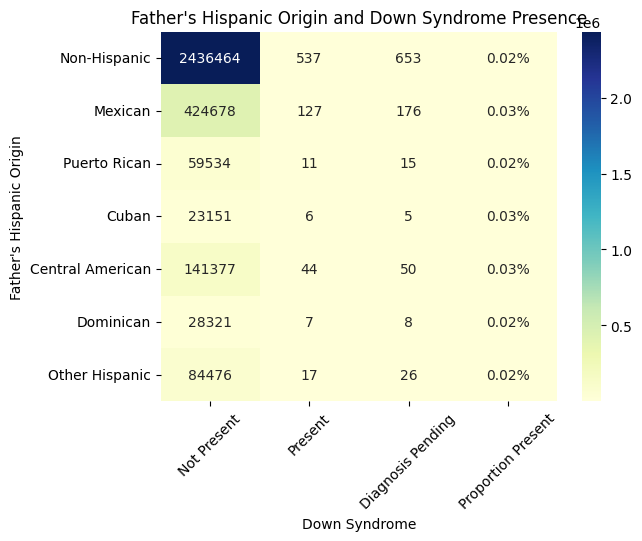

In [35]:
fathers_hispanic_origin_cross_tab = pd.crosstab(
    df[df["fathers_hispanic_origin"] != 9]["fathers_hispanic_origin"], df["target"]
)
fathers_hispanic_origin_cross_tab["proportion"] = (
    round(
        fathers_hispanic_origin_cross_tab[1].astype(float)
        / (
            fathers_hispanic_origin_cross_tab[0]
            + fathers_hispanic_origin_cross_tab[1]
            + fathers_hispanic_origin_cross_tab[2]
        ),
        4,
    )
    * 100
)

annotation_matrix = fathers_hispanic_origin_cross_tab.copy()
annotation_matrix[0:2] = annotation_matrix[0:2].astype(int)
annotation_matrix["proportion"] = round(
    fathers_hispanic_origin_cross_tab["proportion"], 2
)
annotation_matrix["proportion"] = annotation_matrix["proportion"].astype(str) + "%"

fathers_hispanic_origin_cross_tab_ax = sns.heatmap(
    fathers_hispanic_origin_cross_tab,
    cmap="YlGnBu",
    annot=annotation_matrix.values,
    fmt="",
)
fathers_hispanic_origin_cross_tab_ax.set_title(
    "Father's Hispanic Origin and Down Syndrome Presence"
)
fathers_hispanic_origin_cross_tab_ax.set_xlabel("Down Syndrome")
fathers_hispanic_origin_cross_tab_ax.set_xticklabels(
    ["Not Present", "Present", "Diagnosis Pending", "Proportion Present"], rotation=45
)
fathers_hispanic_origin_cross_tab_ax.set_yticklabels(
    [
        "Non-Hispanic",
        "Mexican",
        "Puerto Rican",
        "Cuban",
        "Central American",
        "Dominican",
        "Other Hispanic",
    ],
    rotation=0,
)
fathers_hispanic_origin_cross_tab_ax.set_ylabel("Father's Hispanic Origin")

plt.show()

And the same with the father's Hispanic origin.

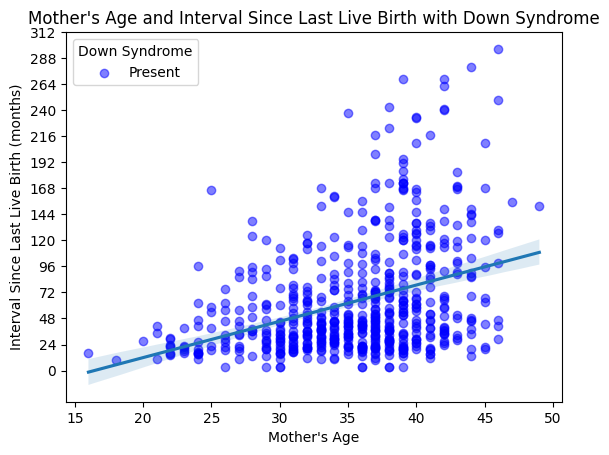

In [36]:
mothers_age_and_interval_since_last_live_birth_ax = sns.regplot(
    data=df[["mothers_single_year_age", "interval_since_last_live_birth", "target"]][
        df["target"] == 1
    ]
    .dropna()
    .astype(int),
    x="mothers_single_year_age",
    y="interval_since_last_live_birth",
    scatter_kws={"alpha": 0.5, "color": "blue"},
)
mothers_age_and_interval_since_last_live_birth_ax.set_title(
    "Mother's Age and Interval Since Last Live Birth with Down Syndrome"
)
mothers_age_and_interval_since_last_live_birth_ax.set_xlabel("Mother's Age")
mothers_age_and_interval_since_last_live_birth_ax.set_ylabel(
    "Interval Since Last Live Birth (months)"
)
mothers_age_and_interval_since_last_live_birth_ax.set_yticks(range(0, 313, 24))
mothers_age_and_interval_since_last_live_birth_ax.set_xticks(range(15, 51, 5))
mothers_age_and_interval_since_last_live_birth_ax.legend(
    title="Down Syndrome", labels=["Present"]
)
plt.show()

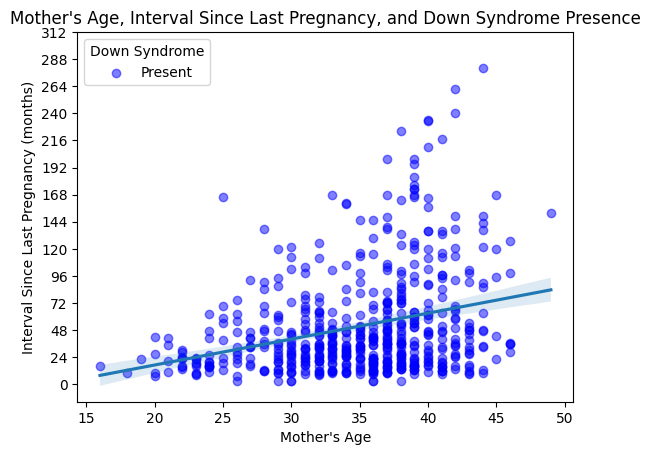

In [37]:
mothers_age_and_interval_since_pregnancy_ax = sns.regplot(
    data=df[
        ["mothers_single_year_age", "interval_since_last_pregnancy_recode", "target"]
    ][df["target"] == 1]
    .dropna()
    .astype(int),
    x="mothers_single_year_age",
    y="interval_since_last_pregnancy_recode",
    scatter_kws={"alpha": 0.5, "color": "blue"},
)
mothers_age_and_interval_since_pregnancy_ax.set_title(
    "Mother's Age, Interval Since Last Pregnancy, and Down Syndrome Presence"
)
mothers_age_and_interval_since_pregnancy_ax.set_xlabel("Mother's Age")
mothers_age_and_interval_since_pregnancy_ax.set_ylabel(
    "Interval Since Last Pregnancy (months)"
)
mothers_age_and_interval_since_pregnancy_ax.set_yticks(range(0, 313, 24))
mothers_age_and_interval_since_pregnancy_ax.set_xticks(range(15, 51, 5))
mothers_age_and_interval_since_pregnancy_ax.legend(
    title="Down Syndrome", labels=["Present"]
)
plt.show()

In [38]:
df["mother_is_hispanic"] = df["mothers_hispanic_origin_recode"].map(
    lambda x: 1 if x in [1, 2, 3, 4, 5, 6] else 0, na_action="ignore"
)

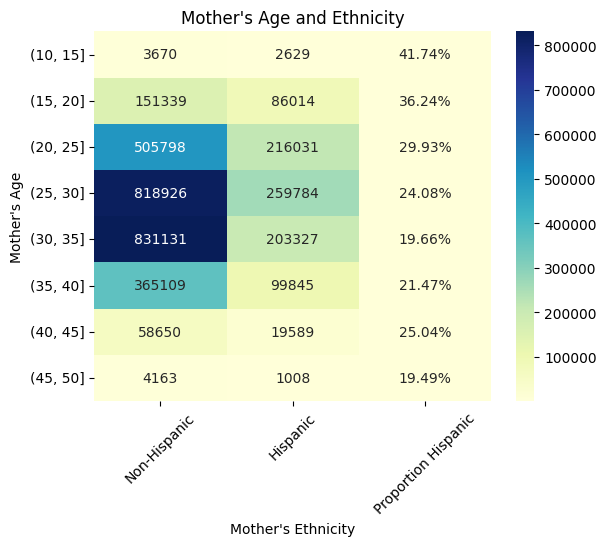

In [39]:
mothers_age_and_ethnicity_cross_tab = pd.crosstab(
    pd.cut(df["mothers_single_year_age"], bins=range(0, 61, 5)),
    df["mother_is_hispanic"],
)
mothers_age_and_ethnicity_cross_tab["proportion_hispanic"] = (
    round(
        mothers_age_and_ethnicity_cross_tab[1].astype(float)
        / (
            mothers_age_and_ethnicity_cross_tab[0].astype(float)
            + mothers_age_and_ethnicity_cross_tab[1].astype(float)
        ),
        4,
    )
    * 100
)

annotation_matrix = mothers_age_and_ethnicity_cross_tab.copy()
annotation_matrix[0:2] = annotation_matrix[0:2].astype(int)
annotation_matrix["proportion_hispanic"] = round(
    mothers_age_and_ethnicity_cross_tab["proportion_hispanic"], 2
)
annotation_matrix["proportion_hispanic"] = (
    annotation_matrix["proportion_hispanic"].astype(str) + "%"
)

mothers_age_and_ethnicity_cross_tab_ax = sns.heatmap(
    mothers_age_and_ethnicity_cross_tab,
    cmap="YlGnBu",
    annot=annotation_matrix.values,
    fmt="",
)
mothers_age_and_ethnicity_cross_tab_ax.set_title("Mother's Age and Ethnicity")
mothers_age_and_ethnicity_cross_tab_ax.set_xlabel("Mother's Ethnicity")
mothers_age_and_ethnicity_cross_tab_ax.set_xticklabels(
    [
        "Non-Hispanic",
        "Hispanic",
        "Proportion Hispanic",
    ],
    rotation=45,
)
mothers_age_and_ethnicity_cross_tab_ax.set_ylabel("Mother's Age")
plt.show()

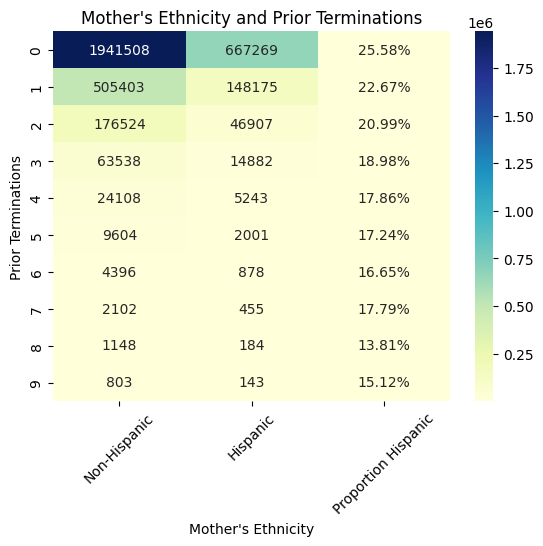

In [40]:
mothers_ethnicity_and_prior_terminations_cross_tab = pd.crosstab(
    df["prior_other_terminations"], df["mother_is_hispanic"]
)
mothers_ethnicity_and_prior_terminations_cross_tab["proportion_hispanic"] = (
    round(
        mothers_ethnicity_and_prior_terminations_cross_tab[1].astype(float)
        / (
            mothers_ethnicity_and_prior_terminations_cross_tab[0].astype(float)
            + mothers_ethnicity_and_prior_terminations_cross_tab[1].astype(float)
        ),
        4,
    )
    * 100
)

annotation_matrix = mothers_ethnicity_and_prior_terminations_cross_tab.copy()
annotation_matrix[0:2] = annotation_matrix[0:2].astype(int)
annotation_matrix["proportion_hispanic"] = round(
    mothers_ethnicity_and_prior_terminations_cross_tab["proportion_hispanic"], 2
)
annotation_matrix["proportion_hispanic"] = (
    annotation_matrix["proportion_hispanic"].astype(str) + "%"
)

mothers_ethnicity_and_prior_terminations_cross_tab_ax = sns.heatmap(
    mothers_ethnicity_and_prior_terminations_cross_tab.iloc[0:10, :],
    cmap="YlGnBu",
    annot=annotation_matrix.iloc[0:10, :].values,
    fmt="",
)
mothers_ethnicity_and_prior_terminations_cross_tab_ax.set_title(
    "Mother's Ethnicity and Prior Terminations"
)
mothers_ethnicity_and_prior_terminations_cross_tab_ax.set_ylabel("Prior Terminations")
mothers_ethnicity_and_prior_terminations_cross_tab_ax.set_xlabel("Mother's Ethnicity")
mothers_ethnicity_and_prior_terminations_cross_tab_ax.set_xticklabels(
    [
        "Non-Hispanic",
        "Hispanic",
        "Proportion Hispanic",
    ],
    rotation=45,
)

plt.show()

### Conclusion

By visualizing our raw data and comparing relative proportions of down syndrome presence among the various factors, we can conclude the following:

- Mother's age appears to be the top predictor, with increased age resulting in increased probability of Down syndrome in the infant.
- Father's age is a close second for top predictor, with the same indication.
- Hispanic origin has some bearing on Down syndrome rates, but research indicates this is largely due to social reasons rather than genetic factors. Hispanic mothers are more likely to concieve at higher ages, and Hispanic parents are less likely to voluntarily terminate when genetic screening indicates a high likelihood of Down syndrome.
- AIAH race also has a higher rate of Down syndrome, for similar reasons as parents of Hispanic origin.
- Cigarettes prior to pregnancy indicates a slight increase in Down syndrome rates, but not enough to indicate a strong correlation.

Of our other features available, none indicate a strong increase in Down syndrome rates. Therefore, our final model will be trained only on the parents' ages.

In [11]:
root = tk.Tk()
root.withdraw()
save_path = filedialog.askdirectory(title="Select Directory to Save JSON Files")

mothers_age_cross_tab.to_json(f"{save_path}/mothers_age_cross_tab.json")
fathers_age_cross_tab.to_json(f"{save_path}/fathers_age_cross_tab.json")
interval_since_last_live_birth_cross_tab.to_json(
    f"{save_path}/interval_since_last_live_birth_cross_tab.json"
)
interval_since_last_pregnancy_cross_tab.to_json(
    f"{save_path}/interval_since_last_pregnancy_cross_tab.json"
)
prior_other_terminations_cross_tab.to_json(
    f"{save_path}/prior_other_terminations_cross_tab.json"
)
prior_births_now_living_cross_tab.to_json(
    f"{save_path}/prior_births_now_living_cross_tab.json"
)
BMI_cross_tab.to_json(f"{save_path}/BMI_cross_tab.json")
pre_pregnancy_weight_cross_tab.to_json(
    f"{save_path}/pre_pregnancy_weight_cross_tab.json"
)
cigarettes_before_pregnancy_cross_tab.to_json(
    f"{save_path}/cigarettes_before_pregnancy_cross_tab.json"
)
mothers_race_cross_tab.to_json(f"{save_path}/mothers_race_cross_tab.json")
mothers_hispanic_origin_cross_tab.to_json(
    f"{save_path}/mothers_hispanic_origin_cross_tab.json"
)
fathers_race_cross_tab.to_json(f"{save_path}/fathers_race_cross_tab.json")
fathers_hispanic_origin_cross_tab.to_json(
    f"{save_path}/fathers_hispanic_origin_cross_tab.json"
)

NameError: name 'mothers_age_cross_tab' is not defined